# Phase 4 Pipeline

Build Phase 4 features, train models, and review results.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

## Build dataset

In [2]:
!python "phase4_extract_dataset.py" --yaml-dir "../../data/raw/ipl_male" --output "results/phase4_dataset.csv"

Saved Phase 4 dataset: results/phase4_dataset.csv (998 rows)


## Train models

In [3]:
!python "phase4_train_pipeline.py" --input "results/phase4_dataset.csv" --results-dir "results" --artifacts-dir "artifacts" --drop-no-result

Phase 4 training: 100%|█████████████| 4/4 [02:53<00:00, 43.44s/model, rf_phase4]
Saved results to: results
Saved artifacts to: artifacts
Best model: extra_trees_phase4
Best model test metrics: {"accuracy": 0.5429, "f1_weighted": 0.5238, "f1_macro": 0.517, "top2_accuracy": 0.9857, "top3_accuracy": 0.9857, "ece": 0.1253}


## Review metrics

In [4]:
results_dir = Path("results")
artifacts_dir = Path("artifacts")

metrics = pd.read_csv(results_dir / "phase4_model_comparison_metrics.csv")
meta = json.loads((artifacts_dir / "phase4_model_metadata.json").read_text(encoding="utf-8"))

display(metrics)
print("Best model:", meta.get("best_model"))
print("Best model params:", meta.get("best_model_params"))
meta.get("best_model_test_metrics", {})

,model,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_f1_weighted,test_f1_weighted,test_f1_macro,test_precision_weighted,test_recall_weighted,test_log_loss,top2_accuracy,top3_accuracy,calibration_ece,fit_gap_weighted_f1,best_cv_accuracy
0,extra_trees_phase4,0.951488,0.542857,0.962324,0.554899,0.953835,0.523752,0.517010,0.585863,0.542857,1.161568,0.985714,0.985714,0.125278,0.430082,0.545741
1,rf_phase4,0.716648,0.528571,0.778373,0.521566,0.707306,0.512732,0.492302,0.613095,0.528571,1.358555,0.985714,0.985714,0.187723,0.194573,0.536926
2,xgboost_phase4,0.545755,0.500000,0.401435,0.521212,0.499917,0.430924,0.423893,0.413224,0.500000,1.521269,0.785714,0.785714,0.121859,0.068993,0.521462
3,logreg_phase4,0.923925,0.428571,0.941729,0.445253,0.923896,0.415629,0.405790,0.477172,0.428571,1.336090,0.885714,0.957143,0.091638,0.508266,0.508324


Best model: extra_trees_phase4
Best model params: {'model__n_estimators': 350, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}


{'train_accuracy': 0.9514884233737596,
 'test_accuracy': 0.5428571428571428,
 'train_balanced_accuracy': 0.9623238689322187,
 'test_balanced_accuracy': 0.5548989898989899,
 'train_f1_weighted': 0.9538348185661129,
 'test_f1_weighted': 0.523752321441397,
 'test_f1_macro': 0.5170099834805717,
 'test_precision_weighted': 0.5858627087198516,
 'test_recall_weighted': 0.5428571428571428,
 'test_log_loss': 1.1615677349814273,
 'top2_accuracy': 0.9857142857142858,
 'top3_accuracy': 0.9857142857142858,
 'calibration_ece': 0.1252778822616412,
 'fit_gap_weighted_f1': 0.4300824971247158,
 'best_cv_accuracy': 0.5457409993321596}

## Review charts

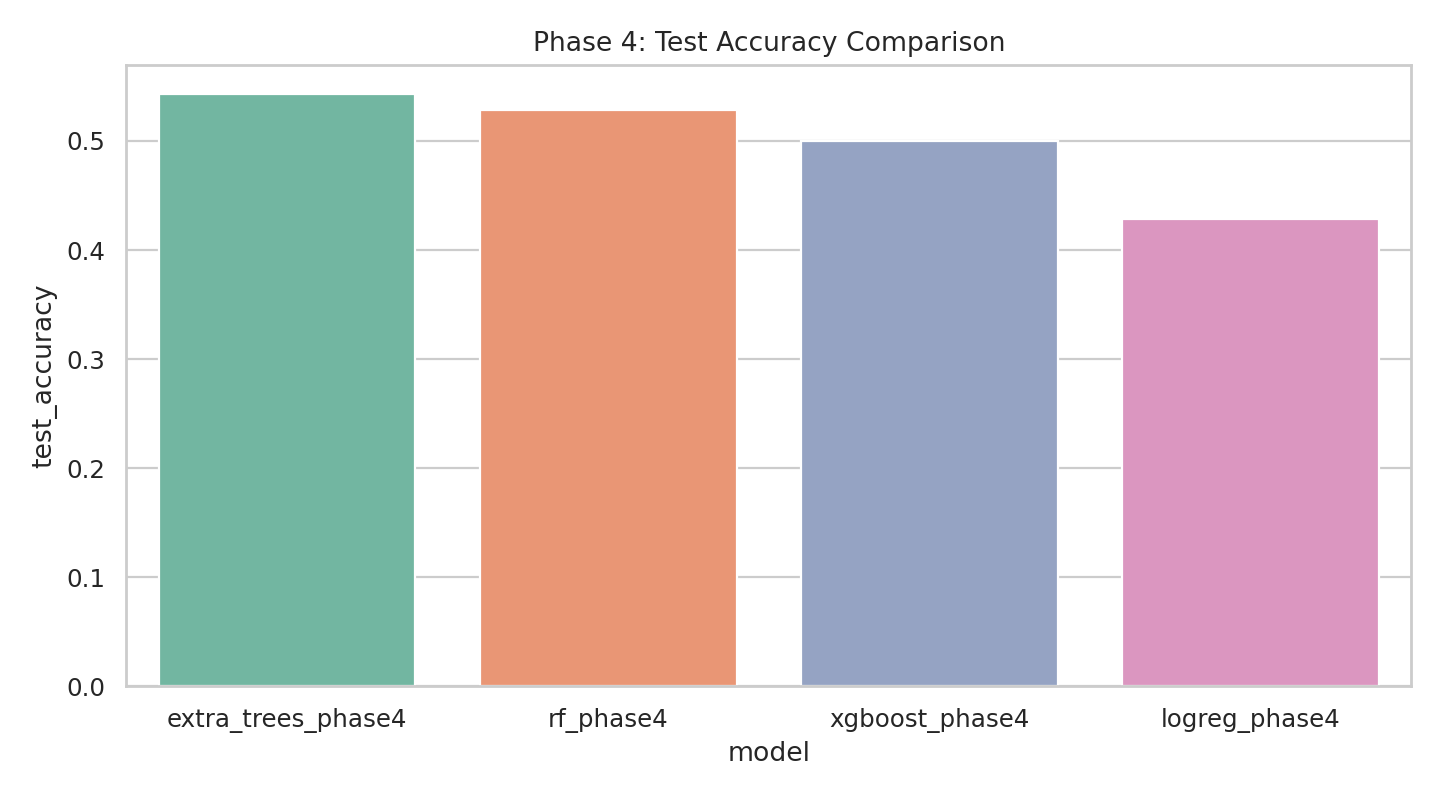

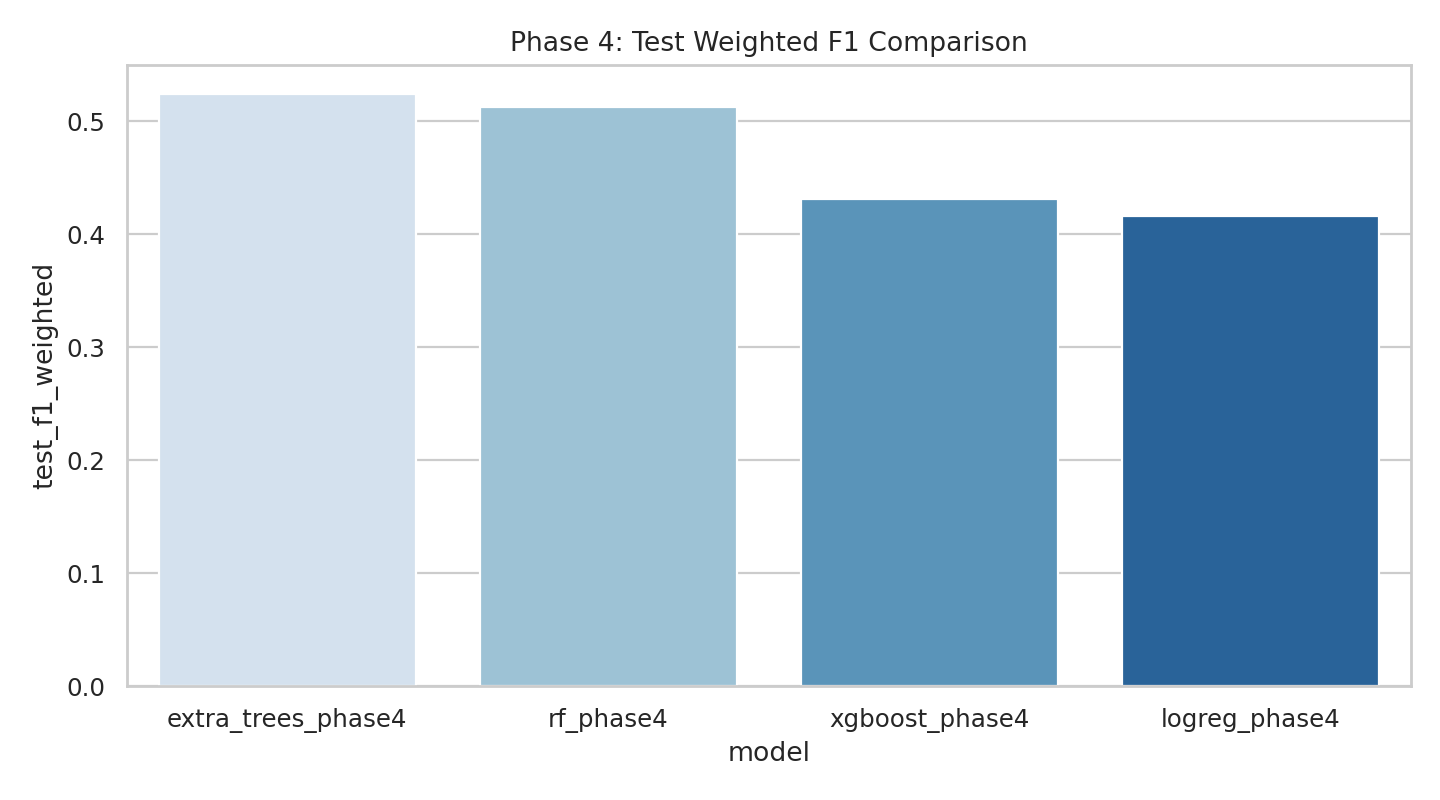

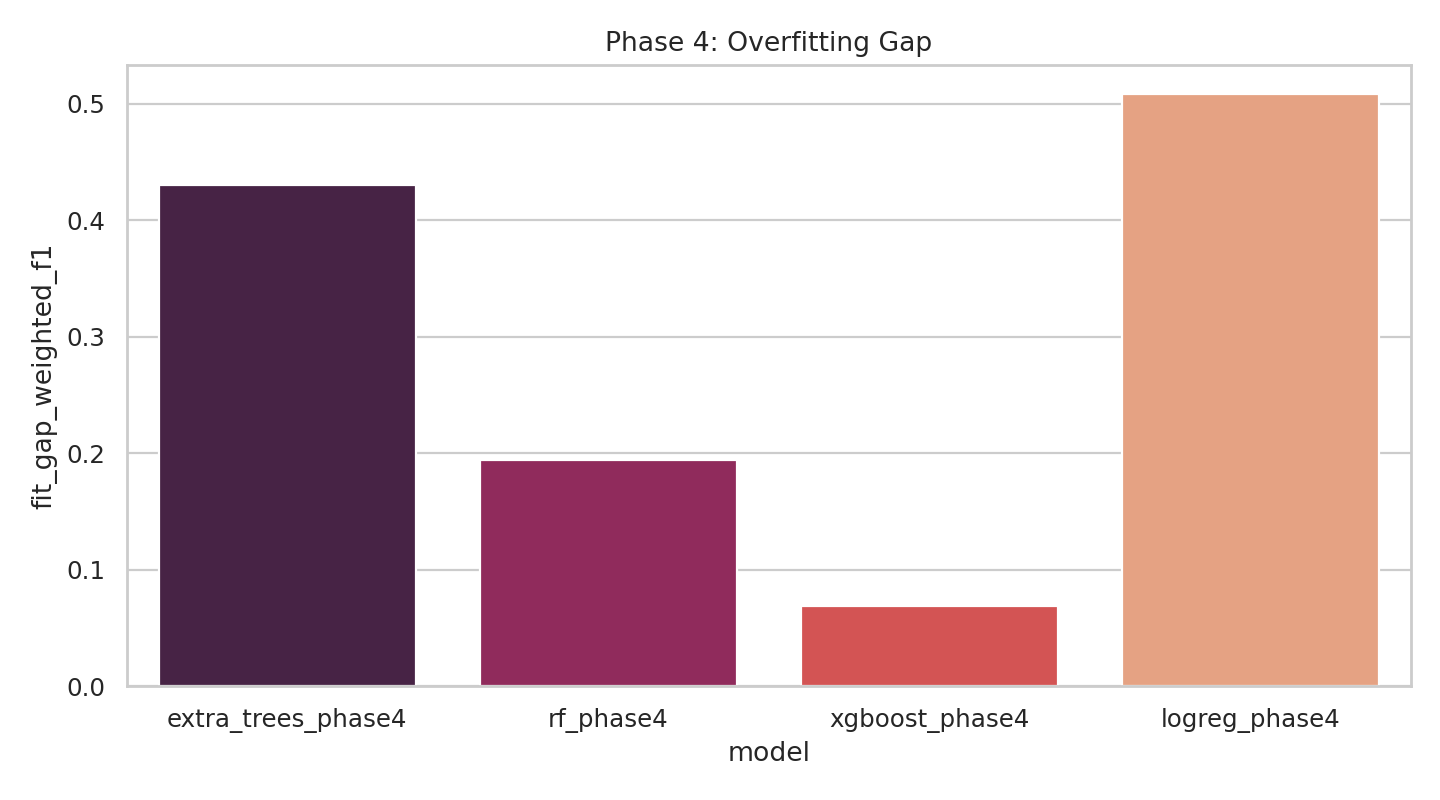

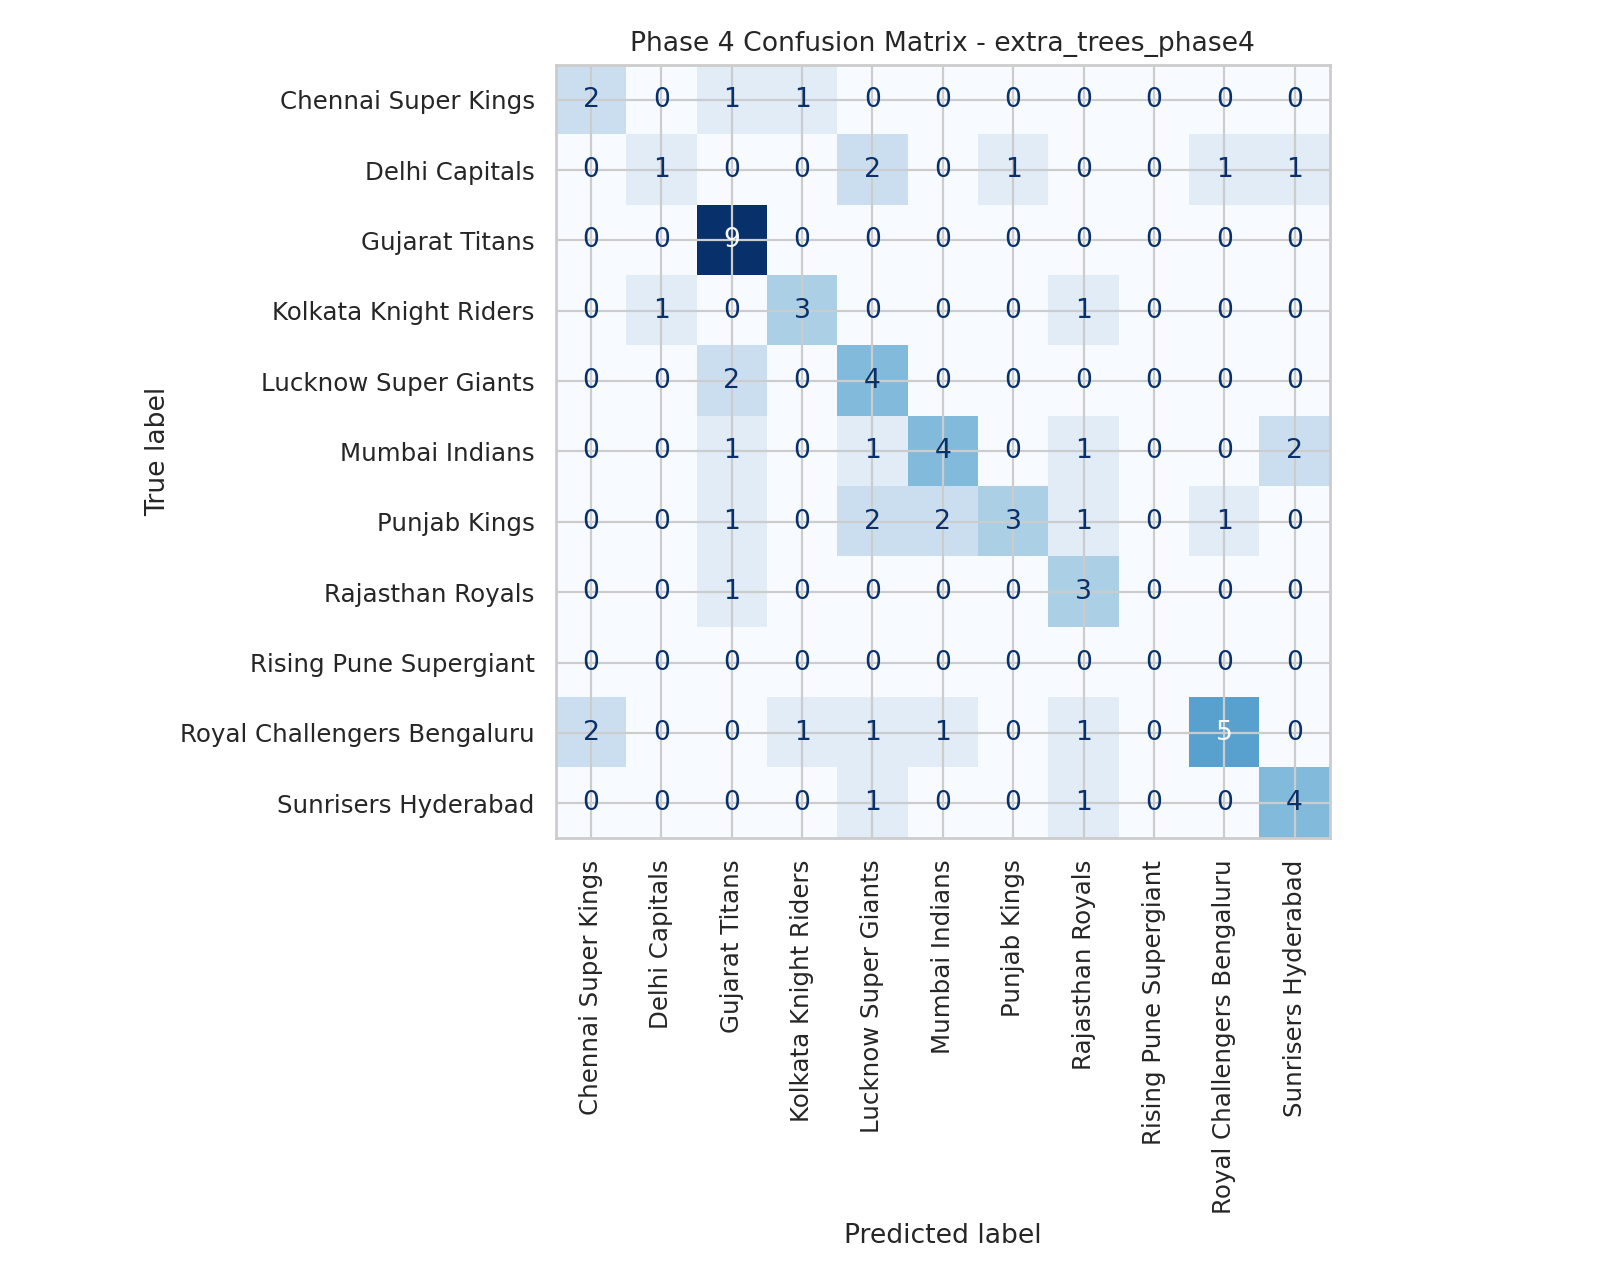

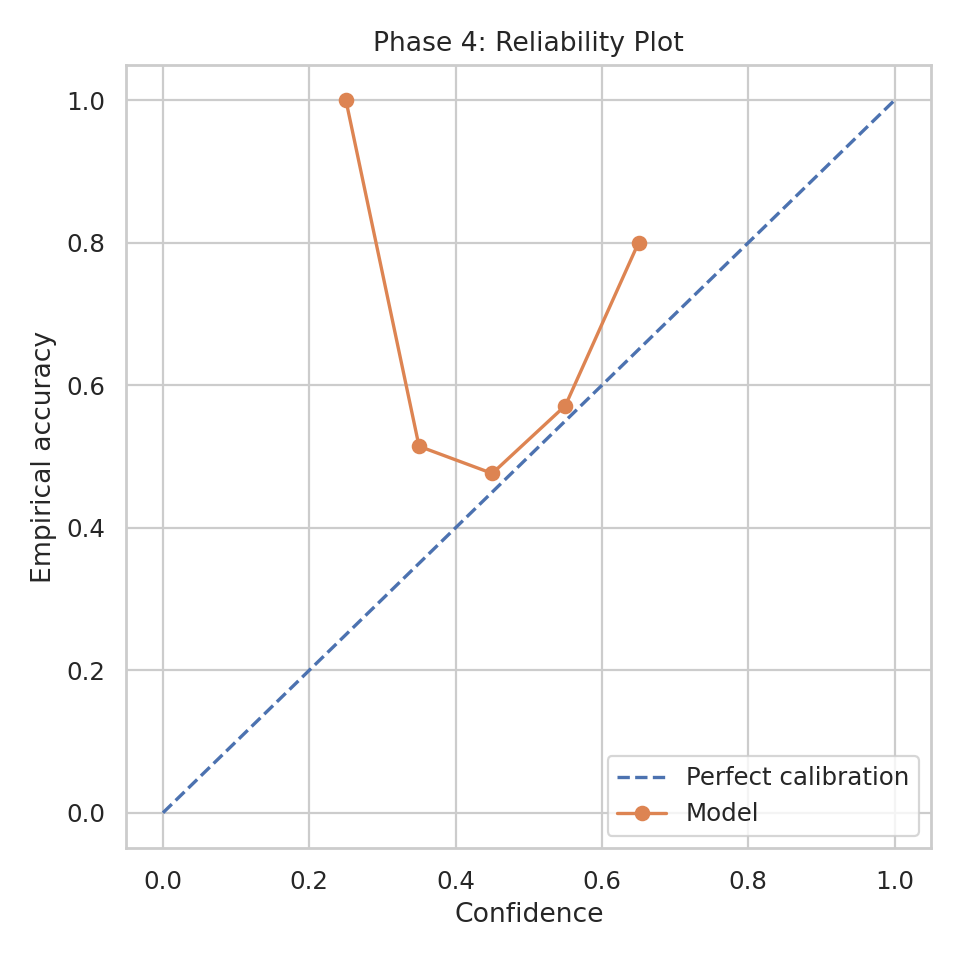

In [5]:
display(Image(filename=str(results_dir / "phase4_model_comparison_accuracy.png")))
display(Image(filename=str(results_dir / "phase4_model_comparison_f1.png")))
display(Image(filename=str(results_dir / "phase4_overfit_gap.png")))
display(Image(filename=str(results_dir / "phase4_best_model_confusion_matrix.png")))
display(Image(filename=str(results_dir / "phase4_best_model_reliability_plot.png")))